    Year  Publications
0   1987             1
1   1988             0
2   1989             4
3   1990             0
4   1991             1
5   1992             3
6   1993             0
7   1994             4
8   1995             1
9   1996             6
10  1997             1
11  1998             3
12  1999             4
13  2000             1
14  2001             3
15  2002             3
16  2003             6
17  2004            10
18  2005             3
19  2006             7
20  2007             8
21  2008             9
22  2009            11
23  2010            11
24  2011            15
25  2012            14
26  2013            11
27  2014            11
28  2015            22
29  2016            20
30  2017            22
31  2018            23
32  2019            42
33  2020            71
34  2021            88
35  2022           107
36  2023           156
37  2024           201
38  2025           380
39  2026          1041
Saved: ./tds_publications_per_year.pdf


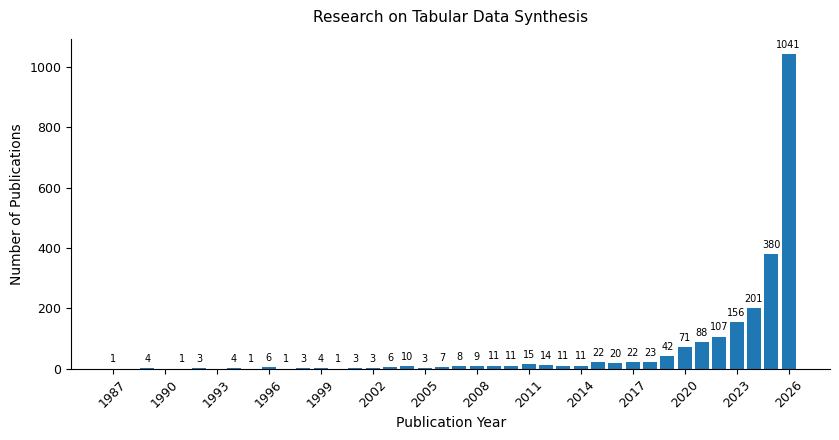

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION
# ============================================================

# Input file
file_path = "TDS_papers_per_year.csv"

# Output directory
results_dir = "."
os.makedirs(results_dir, exist_ok=True)

# Output file
output_path = os.path.join(
    results_dir,
    "tds_publications_per_year.pdf"
)

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(file_path)

# Make sure Year is numeric
df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

# Remove rows without a valid year
df = df.dropna(subset=["Year"])

# Convert year to integer
df["Year"] = df["Year"].astype(int)

# Keep publications from 1987 onward
df = df[df["Year"] >= 1987]

# ============================================================
# COUNT PUBLICATIONS PER YEAR
# ============================================================

publications_per_year = (
    df.groupby("Year")
      .size()
      .reset_index(name="Publications")
      .sort_values("Year")
)

# Add missing years with zero publications
all_years = pd.DataFrame({
    "Year": range(
        1987,
        publications_per_year["Year"].max() + 1
    )
})

publications_per_year = all_years.merge(
    publications_per_year,
    on="Year",
    how="left"
)

publications_per_year["Publications"] = (
    publications_per_year["Publications"]
    .fillna(0)
    .astype(int)
)

print(publications_per_year)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 4.5)
)

bars = ax.bar(
    publications_per_year["Year"],
    publications_per_year["Publications"]
)

# Plot title
ax.set_title(
    "Research on Tabular Data Synthesis",
    fontsize=11,
    pad=12
)

# Axis labels
ax.set_xlabel(
    "Publication Year",
    fontsize=10
)

ax.set_ylabel(
    "Number of Publications",
    fontsize=10
)

# Tick formatting
ax.tick_params(
    axis="both",
    labelsize=9
)

# Show every third year on the x-axis
ax.set_xticks(
    publications_per_year["Year"][::3]
)

ax.tick_params(
    axis="x",
    rotation=45
)

# Add publication count above each non-zero bar
ax.bar_label(
    bars,
    labels=[
        str(value) if value > 0 else ""
        for value in publications_per_year["Publications"]
    ],
    padding=3,
    fontsize=7
)

# Clean dissertation style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    output_path,
    format="pdf",
    bbox_inches="tight"
)

print(f"Saved: {output_path}")

plt.show()
plt.close(fig)